<a href="https://colab.research.google.com/github/kananshr13/CSET-343-Ai-in-Healthcare/blob/main/Lab_Experiment_3_D_CSET_343.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install wfdb -q

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb
from scipy.signal import butter, filtfilt

In [10]:
# Download MIT-BIH Arrhythmia Database
!wget -q -r -N -c -np https://physionet.org/files/mitdb/1.0.0/ -P mitdb

print("Dataset downloaded!")
!find mitdb -maxdepth 5 -type f | head -20

^C
Dataset downloaded!
mitdb/physionet.org/files/mitdb/1.0.0/109.xws
mitdb/physionet.org/files/mitdb/1.0.0/101.xws
mitdb/physionet.org/files/mitdb/1.0.0/214.hea
mitdb/physionet.org/files/mitdb/1.0.0/117.hea
mitdb/physionet.org/files/mitdb/1.0.0/103.xws
mitdb/physionet.org/files/mitdb/1.0.0/116.xws
mitdb/physionet.org/files/mitdb/1.0.0/219.hea
mitdb/physionet.org/files/mitdb/1.0.0/202.atr
mitdb/physionet.org/files/mitdb/1.0.0/215.dat
mitdb/physionet.org/files/mitdb/1.0.0/220.hea
mitdb/physionet.org/files/mitdb/1.0.0/114.xws
mitdb/physionet.org/files/mitdb/1.0.0/121.xws
mitdb/physionet.org/files/mitdb/1.0.0/222.at_
mitdb/physionet.org/files/mitdb/1.0.0/119.xws
mitdb/physionet.org/files/mitdb/1.0.0/209.xws
mitdb/physionet.org/files/mitdb/1.0.0/200.hea
mitdb/physionet.org/files/mitdb/1.0.0/114.atr
mitdb/physionet.org/files/mitdb/1.0.0/108.hea
mitdb/physionet.org/files/mitdb/1.0.0/112.dat
mitdb/physionet.org/files/mitdb/1.0.0/102-0.atr


In [11]:
import glob

dat_files = glob.glob("mitdb/**/*.dat", recursive=True)

print("Number of ECG records found:", len(dat_files))
print("Sample files:", dat_files[:10])

Number of ECG records found: 44
Sample files: ['mitdb/physionet.org/files/mitdb/1.0.0/215.dat', 'mitdb/physionet.org/files/mitdb/1.0.0/112.dat', 'mitdb/physionet.org/files/mitdb/1.0.0/210.dat', 'mitdb/physionet.org/files/mitdb/1.0.0/203.dat', 'mitdb/physionet.org/files/mitdb/1.0.0/119.dat', 'mitdb/physionet.org/files/mitdb/1.0.0/220.dat', 'mitdb/physionet.org/files/mitdb/1.0.0/228.dat', 'mitdb/physionet.org/files/mitdb/1.0.0/207.dat', 'mitdb/physionet.org/files/mitdb/1.0.0/124.dat', 'mitdb/physionet.org/files/mitdb/1.0.0/117.dat']


In [12]:

record_path = dat_files[0].replace(".dat", "")

record = wfdb.rdrecord(record_path)

signal = record.p_signal[:, 0]
fs = record.fs

print("Record:", record_path)
print("Sampling frequency:", fs, "Hz")
print("Signal length:", len(signal))
print("Duration:", len(signal) / fs, "seconds")

Record: mitdb/physionet.org/files/mitdb/1.0.0/215
Sampling frequency: 360 Hz
Signal length: 650000
Duration: 1805.5555555555557 seconds


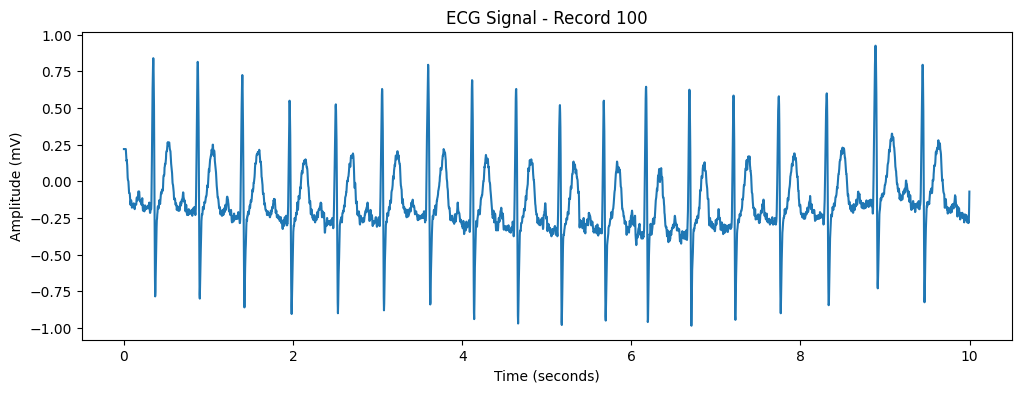

In [13]:
time = np.arange(len(signal)) / fs

plt.figure(figsize=(12,4))
plt.plot(time[:10*int(fs)], signal[:10*int(fs)])
plt.title("ECG Signal - Record 100")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.show()

In [14]:
print("Minimum:", signal.min())
print("Maximum:", signal.max())
print("Mean:", signal.mean())
print("Standard deviation:", signal.std())
print("Missing values:", np.isnan(signal).sum())

Minimum: -1.38
Maximum: 2.5
Mean: -0.1519386153846154
Standard deviation: 0.28203105339320855
Missing values: 0


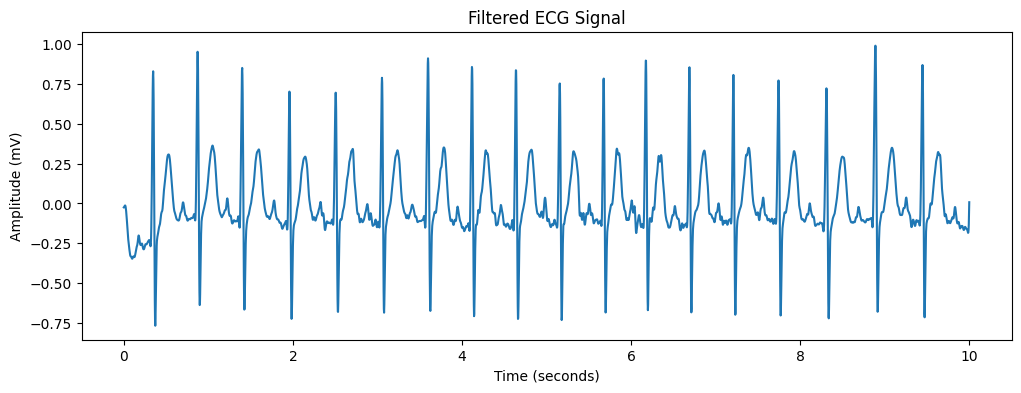

In [15]:
# Band-pass filter: 0.5–40 Hz
lowcut = 0.5
highcut = 40

b, a = butter(
    4,
    [lowcut/(fs/2), highcut/(fs/2)],
    btype="band"
)

filtered_signal = filtfilt(b, a, signal)

plt.figure(figsize=(12,4))
plt.plot(time[:10*int(fs)], filtered_signal[:10*int(fs)])
plt.title("Filtered ECG Signal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude (mV)")
plt.show()

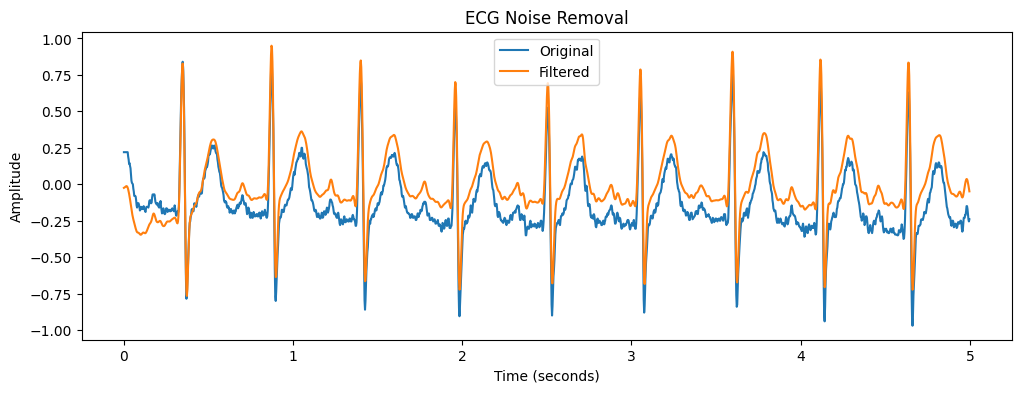

In [16]:
plt.figure(figsize=(12,4))

plt.plot(time[:5*int(fs)], signal[:5*int(fs)], label="Original")
plt.plot(time[:5*int(fs)], filtered_signal[:5*int(fs)], label="Filtered")

plt.title("ECG Noise Removal")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.show()

In [17]:
normalized_signal = (
    filtered_signal - np.mean(filtered_signal)
) / np.std(filtered_signal)

print("Mean:", normalized_signal.mean())
print("Standard deviation:", normalized_signal.std())

Mean: -1.7462954159642463e-18
Standard deviation: 1.0


In [18]:
segment_length = int(2 * fs)

segments = []

for i in range(0, len(normalized_signal) - segment_length, segment_length):
    segments.append(
        normalized_signal[i:i + segment_length]
    )

segments = np.array(segments)

print("Segment shape:", segments.shape)

Segment shape: (902, 720)


In [19]:
features = pd.DataFrame({
    "Mean": np.mean(segments, axis=1),
    "Std": np.std(segments, axis=1),
    "Min": np.min(segments, axis=1),
    "Max": np.max(segments, axis=1),
    "RMS": np.sqrt(np.mean(segments**2, axis=1))
})

features.head()

,Mean,Std,Min,Max,RMS
0,-0.114968,0.906982,-2.809673,3.486010,0.914239
1,0.015756,0.774868,-2.509832,3.335260,0.775028
2,0.004702,0.848899,-2.679304,3.136834,0.848912
3,0.020970,0.838395,-2.574222,3.283815,0.838657
4,-0.056491,0.798602,-2.639735,3.624994,0.800598


In [20]:
features.describe()

,Mean,Std,Min,Max,RMS
count,902.000000,902.000000,902.000000,902.000000,902.000000
mean,0.000033,0.981526,-2.756500,4.352053,0.982044
std,0.032499,0.188702,0.162141,1.561821,0.188805
min,-0.176669,0.581435,-4.376454,2.168420,0.581476
25%,-0.022254,0.884519,-2.842215,3.596211,0.884781
50%,0.003733,0.924662,-2.758902,3.803901,0.924963
75%,0.020567,0.973840,-2.678128,4.077399,0.974146
max,0.169282,1.935699,-1.225752,9.858168,1.935750


In [21]:
X_signal = segments

print("Model-ready shape:", X_signal.shape)
print("Each sample contains", X_signal.shape[1], "ECG points")

Model-ready shape: (902, 720)
Each sample contains 720 ECG points


In [22]:
print("Signal preprocessing completed!")
print("Dataset: MIT-BIH Arrhythmia Database")
print("Signal: ECG")
print("Noise removal: 0.5–40 Hz band-pass filter")
print("Normalization: Z-score")
print("Segmentation: 2-second windows")
print("Features: Mean, Std, Min, Max, RMS")
print("Model-ready format: ECG signal segments")

Signal preprocessing completed!
Dataset: MIT-BIH Arrhythmia Database
Signal: ECG
Noise removal: 0.5–40 Hz band-pass filter
Normalization: Z-score
Segmentation: 2-second windows
Features: Mean, Std, Min, Max, RMS
Model-ready format: ECG signal segments
